**Import Libraries**

In [256]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display

**Grid World Definition**

In [257]:
grid_size = 10

lake = (1, 1)
fire = (8, 8)

smoke = {
    (2,2),(2,3),(2,4),
    (3,2),(4,2),
    (5,7),(6,7),(7,7),
    (7,5),(7,6),
    (4,5),(4,6)
}

boulders = {
    (1,4),(2,4),(3,4),(4,4),(5,4),
    (6,1),(6,2),(6,3),(6, 0),
    (8,6),(8,7),(7,8)
}

actions = ["N", "S", "E", "W", "H"]

gamma = 0.95
theta = 1e-8


**State Space**

In [258]:
states = [(r, c, w)
          for r in range(grid_size)
          for c in range(grid_size)
          for w in [0, 1]]

**Movement**

In [259]:
def move(r, c, action):

    nr, nc = r, c

    if action == "N":
        nr -= 1
    elif action == "S":
        nr += 1
    elif action == "E":
        nc += 1
    elif action == "W":
        nc -= 1

    if nr < 0 or nr >= grid_size or nc < 0 or nc >= grid_size:
        return r, c

    if (nr, nc) in boulders:
        return r, c

    return nr, nc

**Transition Function**

In [260]:
def get_transitions(state, action):

    r, c, w = state

    if action == "H":
        next_w = 1 if (r, c) == lake else w
        return [(r, c, next_w, 1.0)]

    if (r, c) in smoke:
        intended = 0.4
        stay = 0.4
        side = 0.1
    else:
        intended = 0.7
        stay = 0.1
        side = 0.1

    if action in ["N", "S"]:
        perp = ["E", "W"]
    else:
        perp = ["N", "S"]

    outcomes = []

    directions = [(action, intended),
                  (perp[0], side),
                  (perp[1], side),
                  ("H", stay)]

    for act, prob in directions:

        if act == "H":
            nr, nc = r, c
        else:
            nr, nc = move(r, c, act)

        nw = 1 if (nr, nc) == lake else w
        outcomes.append((nr, nc, nw, prob))

    return outcomes

**Reward Function**

In [261]:
def reward(next_state):

    r, c, w = next_state

    if (r, c) in boulders:
        return -500

    if (r, c) in smoke:
        return -100
    
    if (r, c) == lake and w == 0:
        return 500

    if (r, c) == fire and w == 1:
        return 1000

    return -10

**Terminal Condition Check**

In [262]:
def is_terminal(state):

    r, c, w = state

    if (r, c) in boulders:
        return True

    if (r, c) == fire and w == 1:
        return True

    return False

**Value Iteration**

In [263]:
V = {state: 0 for state in states}
policy = {state: None for state in states}

while True:

    delta = 0

    for state in states:

        if is_terminal(state):
            continue

        best_value = -1e9
        best_action = None

        for action in actions:

            total = 0

            for nr, nc, nw, prob in get_transitions(state, action):

                next_state = (nr, nc, nw)
                rwd = reward(next_state)

                if is_terminal(next_state):
                    total += prob * rwd
                else:
                    total += prob * (rwd + gamma * V[next_state])

            if total > best_value:
                best_value = total
                best_action = action

        delta = max(delta, abs(best_value - V[state]))
        V[state] = best_value
        policy[state] = best_action

    if delta < theta:
        break

print("Value Iteration Converged")

Value Iteration Converged


**Value Function Plot Visualization**

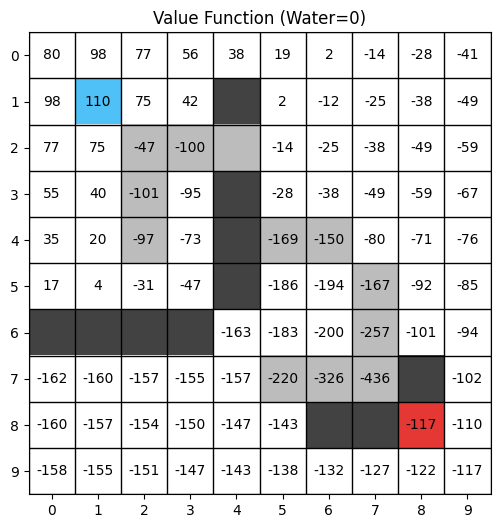

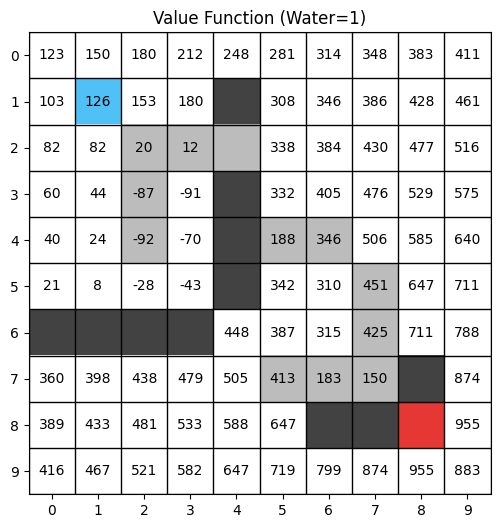

In [264]:
def plot_value_function(water_state):

    fig, ax = plt.subplots(figsize=(6,6))

    color_grid = np.ones((grid_size, grid_size, 3))
    values = np.zeros((grid_size, grid_size))

    for r in range(grid_size):
        for c in range(grid_size):

            values[r,c] = V[(r,c,water_state)]

            if (r,c) == lake:
                color_grid[r,c] = [0.31,0.76,0.97]   # #4FC3F7

            elif (r,c) == fire:
                color_grid[r,c] = [0.90,0.22,0.21]   # #E53935

            elif (r,c) in smoke:
                color_grid[r,c] = [0.74,0.74,0.74]   # #BDBDBD

            elif (r,c) in boulders:
                color_grid[r,c] = [0.26,0.26,0.26]   # #424242

            else:
                color_grid[r,c] = [1,1,1]            # white

    ax.imshow(color_grid)

    # draw values
    for r in range(grid_size):
        for c in range(grid_size):

            if is_terminal((r,c,water_state)):
                continue

            ax.text(
                c, r,
                f"{values[r,c]:.0f}",
                ha="center",
                va="center",
                color="black"
            )

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))

    ax.set_xticks(np.arange(-.5,grid_size,1),minor=True)
    ax.set_yticks(np.arange(-.5,grid_size,1),minor=True)

    ax.grid(which="minor",color="black",linewidth=1)
    ax.tick_params(which="minor",bottom=False,left=False)

    ax.set_title(f"Value Function (Water={water_state})")

    plt.show()

plot_value_function(0)
plot_value_function(1)

**Policy Plot Visualization**

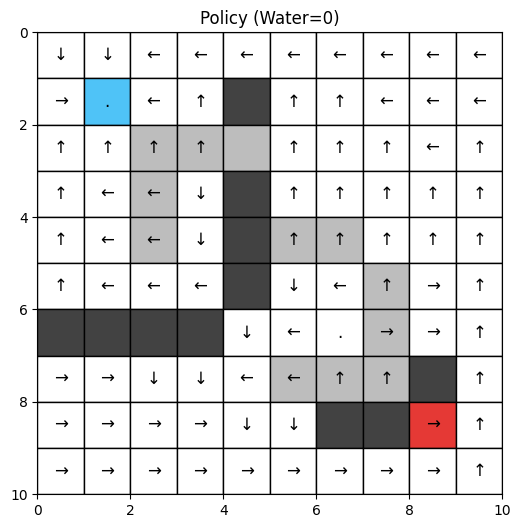

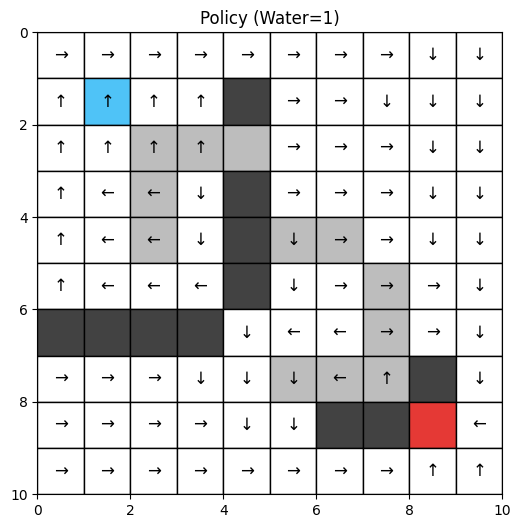

In [265]:
def plot_policy(water_state):

    arrow_map = {
        "N":"↑",
        "S":"↓",
        "E":"→",
        "W":"←",
        "H":"."
    }

    fig, ax = plt.subplots(figsize=(6,6))

    for r in range(grid_size):
        for c in range(grid_size):

            if (r,c) == lake:
                color = "#4FC3F7"
            elif (r,c) == fire:
                color = "#E53935" 
            elif (r,c) in smoke:
                color = "#BDBDBD"  
            elif (r,c) in boulders:
                color = "#424242"  
            else:
                color = "white"

            rect = plt.Rectangle((c, r),1,1,facecolor=color,edgecolor="black")
            ax.add_patch(rect)

            if (r,c) not in boulders:

                action = policy[(r,c,water_state)]

                if action is not None:
                    ax.text(c+0.5,r+0.5,arrow_map[action],
                            ha='center',va='center',fontsize=12)

    ax.set_xlim(0,grid_size)
    ax.set_ylim(0,grid_size)
    ax.invert_yaxis()
    ax.set_title(f"Policy (Water={water_state})")
    plt.show()

plot_policy(0)
plot_policy(1)

**Drone Simulation**

In [266]:
def simulate(start_state, max_steps=500):

    state = start_state
    trajectory = [state]

    for _ in range(max_steps):

        if is_terminal(state):
            break

        action = policy[state]

        transitions = get_transitions(state, action)

        probs = [t[3] for t in transitions]
        choice = np.random.choice(len(transitions), p=probs)

        nr, nc, nw, _ = transitions[choice]
        state = (nr, nc, nw)

        trajectory.append(state)

    return trajectory

**Frame Renderer**

In [267]:
def render_frame(state):

    r, c, w = state

    fig, ax = plt.subplots(figsize=(6,6))

    color_grid = np.ones((grid_size, grid_size, 3))

    for i in range(grid_size):
        for j in range(grid_size):

            if (i, j) == lake:
                color_grid[i, j] = [0,0,1]
            elif (i, j) == fire:
                color_grid[i, j] = [1,0,0]
            elif (i, j) in smoke:
                color_grid[i, j] = [0.7,0.7,0.7]
            elif (i, j) in boulders:
                color_grid[i, j] = [0.2,0.2,0.2]

    ax.imshow(color_grid)

    ax.scatter(c,r,s=200)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))

    ax.set_xticks(np.arange(-.5,grid_size,1),minor=True)
    ax.set_yticks(np.arange(-.5,grid_size,1),minor=True)

    ax.grid(which="minor",color="black")

    ax.set_title(f"Drone | Water={w}")

    plt.close(fig)

    fig.canvas.draw()

    frame = np.array(fig.canvas.buffer_rgba())

    return frame

**Generate GIF**

GIF saved!


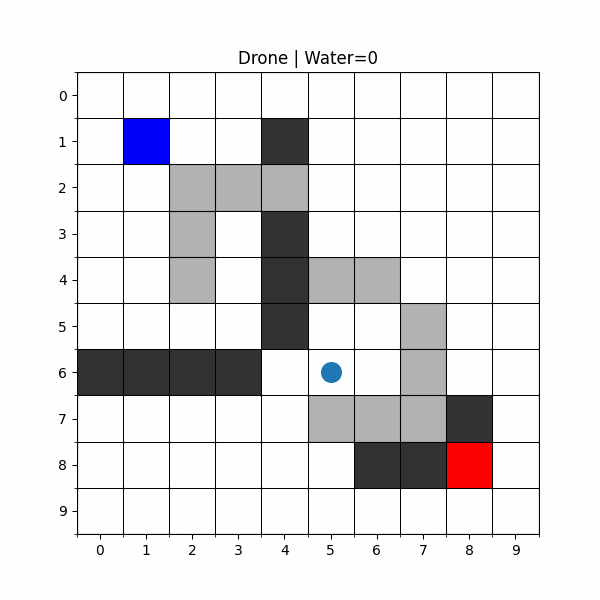

In [268]:
trajectory = simulate((6,5,0))

frames = []

for s in trajectory:
    frames.append(render_frame(s))

gif_path = "drone_simulation.gif"

imageio.mimsave(gif_path,frames,fps=8)

print("GIF saved!")

display(Image(filename=gif_path))